---
title: Leela Interp Demo with NNsight
jupyter:
  jupytext:
    text_representation:
      extension: .qmd
      format_name: quarto
      format_version: '1.0'
      jupytext_version: 1.19.4
  kernelspec:
    display_name: chess-interp (3.14.4)
    language: python
    name: python3
---



## Setup

In [3]:
import sys
import os
from pathlib import Path

# Import modules from parent and sibling directories
current_dir = Path.cwd().resolve()
repo_root = current_dir.parent if current_dir.name == "leela_interp" else current_dir
leela_pytorch_impl_dir = repo_root / "leela_pytorch_impl"

for path in (repo_root, leela_pytorch_impl_dir):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.append(path_str)

from model import Lc0Model
from leela_board import LeelaBoard
import torch
import numpy as np
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import train_test_split, cross_val_score

In [4]:
ONNX_MODEL_NAME = 'lc0.onnx'
lc0 = Lc0Model(onnx_model_path=os.path.join(leela_pytorch_impl_dir, ONNX_MODEL_NAME))

Using device: cpu


### Hugging Face Authentication

We load local `.env` variables and initialize our token to fetch the chess evaluation sets from Hugging Face properly.

In [5]:
from dotenv import load_dotenv
from huggingface_hub import login

load_dotenv()  # Load environment variables from .env file

login(token=os.getenv("HUGGINGFACE_TOKEN"))

## Dataset

We will use a sample chess dataset to run our first probe on the model

In [6]:
from datasets import IterableDataset, iterable_dataset, load_dataset

print("1. Load actual dataset (streaming)")
try:
    # Trying lowercase to see if it fixes the typo
    data = load_dataset("Lichess/chess-puzzles", split="train", streaming=True)
except Exception as e:
    print(f"Failed to load: {e}")

1. Load actual dataset (streaming)


### Streaming the Dataset & Filtering

We stream the dataset from Hugging Face instead of downloading it fully into memory to prevent crashing. We also selectively filter the incoming stream to extract exactly 500 puzzle positions.

In [7]:
import chess
def get_nth(iterable:IterableDataset, n:int, default=None):
    for i, x in enumerate(iterable):
        if i == n:
            return x
    return default

item = get_nth(data, 3)
fen = item['FEN']
board = LeelaBoard.from_fen(fen)

In [6]:
item

{'PuzzleId': '0009B',
 'GameId': '4MWQCxQ6/black#32',
 'FEN': 'r2qr1k1/b1p2ppp/pp4n1/P1P1p3/4P1n1/B2P2Pb/3NBP1P/RN1QR1K1 b - - 1 16',
 'Moves': 'b6c5 e2g4 h3g4 d1g4',
 'Rating': 1084,
 'RatingDeviation': 74,
 'Popularity': 88,
 'NbPlays': 606,
 'Themes': ['advantage', 'middlegame', 'short'],
 'OpeningTags': ['Kings_Pawn_Game', 'Kings_Pawn_Game_Leonardis_Variation']}

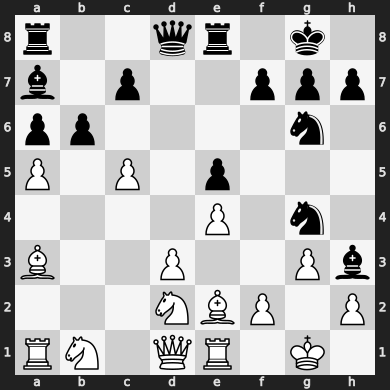

In [7]:
board

In [17]:
print("2. Extract Boards and Labels (Balanced)")
boards = []
num_boards = 0

target_num = 1000

# These arrays will contain a number 0-63 that represent a square on the chessboard
first_source_indexes = np.zeros(target_num, dtype=int)
first_target_indexes = np.zeros(target_num, dtype=int)
lookahead_source_indexes = np.zeros(target_num, dtype=int)
lookahead_target_indexes = np.zeros(target_num, dtype=int)

# must be minimum 2
LOOKAHEAD_NUM = 1+1

known_fens = set()
for i, item in enumerate(data):
    fen = item.get('FEN', item.get('fen'))
    if fen in known_fens:
        continue;
    else:
        known_fens.add(fen)
        
    board = LeelaBoard.from_fen(fen)
    # Ex: ["e2e4", "e7e5"]
    moves = item['Moves'].split(' ')

    # 1 because the puzzle must start with a move
    # *2 because a "move" is a pair of moves
    if len(moves)<1+LOOKAHEAD_NUM*2:
        continue;

    # Puzzle data starts one move from the start of the puzzl
    # This move is given to the player. i.e. it is played by enemy
    start_uci = moves[0]
    board.push_uci(start_uci)
    boards.append(board)
    # We consider this the first real move.
    # This is the first move that a player would have to find
    first_uci = moves[1]
    first_source_indexes[num_boards] = board.sq2idx(first_uci[0:2])
    first_target_indexes[num_boards] = board.sq2idx(first_uci[2:4])

    # in the case where the game should end before lookahead don't include
    try:
        lookahead_uci = moves[2*LOOKAHEAD_NUM]
    except Exception as e:
        print(moves[2])
        continue
    
    lookahead_source_indexes[num_boards] = board.sq2idx(lookahead_uci[0:2])
    lookahead_target_indexes[num_boards] = board.sq2idx(lookahead_uci[2:4])

    num_boards += 1

    if num_boards >= target_num:
        break;

print(f"Found {num_boards} positions.")

2. Extract Boards and Labels (Balanced)
Found 500 positions.


In [18]:
labels = np.array(lookahead_target_indexes, dtype=int)

In [19]:
print("3. Force model and inputs to CPU")
lc0.cpu() # ensure everything is on CPU to avoid device mismatch
lc0._device = 'cpu'
inputs = lc0.make_inputs(boards).cpu()

3. Force model and inputs to CPU


## Extracting Activations

Here we construct inputs for the model and run the PyTorch forward pass. We use NNsight to intercept the outputs of the Multi-Layer Perceptron (MLP) at our designated probe layer (`LAYER_TO_PROBE = 10`). 

In [20]:
from nnsight import NNsight

print("Run forward pass and extract activations with NNsight...")
# has 15 layers total
LAYER_TO_PROBE = 10

# Wrap our model in NNsight
nnsight_model = NNsight(lc0)

with nnsight_model.trace(inputs) as tracer:
    # Grab the output of the residual stream
    hidden_states = nnsight_model._lc0_model.post_mlp[LAYER_TO_PROBE].output.save()

print("Extracting features")
X_activations = hidden_states if isinstance(hidden_states, torch.Tensor) else hidden_states.value
print(f"Activations shape: {X_activations.shape}")

batch_idx = torch.arange(target_num, dtype=int)
i1 = torch.from_numpy(first_source_indexes)
i2 = torch.from_numpy(first_target_indexes)

# Represent the hiddens layers for the targets
# Should be of the form [batches, h_dim]
first_source_h = X_activations[batch_idx, i1].to("gpu")
first_target_h = X_activations[batch_idx, i2].to("gpu")

Run forward pass and extract activations with NNsight...


/home/colin-doherty/Documents/Coding/AI/chess-interp/.venv/lib/python3.14/site-packages/onnx2torch/node_converters/slice.py:63: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  x = x[pos_axes_slices]


Extracting features
Activations shape: torch.Size([500, 64, 768])


# Finding the shape

What is the shape the Query and Key Matricies?

In [24]:
for name, module in lc0.named_modules():
    print(name)
    print(module)


Lc0Model(
  (_lc0_model): GraphModule(
    (attn_body/transpose): OnnxTranspose()
    (initializers): Module()
    (attn_body/reshape): OnnxReshape()
    (attn_body/shape): OnnxShape()
    (attn_body/batch): OnnxSlice()
    (attn_body/pos_encoding_shape): OnnxConcat()
    (attn_body/expand): OnnxExpand()
    (attn_body/padded_input): OnnxConcat()
    (attn_body/reshape2): OnnxReshape()
    (attn_body/matmul): OnnxMatMul()
    (attn_body/add): OnnxBinaryMathOperation()
    (attn_body/mish/softplus): Softplus(beta=1.0, threshold=20.0)
    (attn_body/mish/tanh): OnnxFunction()
    (attn_body/mish): OnnxBinaryMathOperation()
    (attn_body/ma_gating/rehape1): OnnxReshape()
    (ip_mul_gate): OnnxBinaryMathOperation()
    (ip_add_gate): OnnxBinaryMathOperation()
    (attn_body/ma_gating/rehape2): OnnxReshape()
    (encoder0/mha/Q/w): OnnxMatMul()
    (encoder0/mha/Q/b): OnnxBinaryMathOperation()
    (encoder0/mha/Q/reshape): OnnxReshape()
    (encoder0/mha/Q/transpose): OnnxTranspose()
   

In [13]:
with nnsight_model.trace(inputs) as tracer:
    # Grab the output of the residual stream
    step = getattr(nnsight_model._lc0_model, 'encoder10/mha/Q/w')
    attn_states = step.output.save()

print(attn_states)
print(f"shape: {attn_states}")

KeyboardInterrupt: 

shape is of the form [BATCH_SIZE * 64, H_DIM]

In other words, the matricies are really (64, 768)

# Training the Linear Probe

After capturing the activations from our hidden layer, we split the data and train a Logistic Regression classifier (`Linear Probe`) with 5-fold cross-validation on the intermediate layer's geometry to see if it implicitly "understands" the concept of 'check'.

In [ ]:
import torch
import torch.nn as nn

class BilinearProbe(nn.Module):
    def __init__(self, d_attn, d_h, num_squares = 64):
        """
        d_attn: 64  — attention/bottleneck dimension (also num squares)
        d_h:   768  — hidden state dimension
        """
        super().__init__()
        self.U = nn.Parameter(torch.randn(d_attn, d_h) * 0.01)  # (64, 768)
        self.V = nn.Parameter(torch.randn(d_attn, d_h) * 0.01)  # (64, 768)
        self.c = nn.Parameter(torch.zeros(num_squares))              # (64,)

    def forward(self, h_y_all, h_t1):
        """
        h_y_all: (B, num_sqaures, d_h)  — h^L for each candidate square y
        h_t1:    (B, d_h)     — h^L at position t1
        Returns:  (B, num_squares)     — one logit per square, ready to softmax
        """
        # Project candidate squares: (B, num_squares, d_h) @ (d_h, d_attn) -> (B, num_squares, d_attn)
        Uh = h_y_all @ self.U.T

        # Project conditioning token: (B, d_h) @ (d_h, d_attn) -> (B, d_attn)
        Vh = h_t1 @ self.V.T

        # (B, num_sqaures, d_attn) @ (B, d_attn, 1) -> (B, num_squares, 1) -> (B, num_sqaures)
        logits = (Uh @ Vh.unsqueeze(-1))\
        .squeeze(-1) + self.c
        return logits
    
    def predict(self, h_y_all, h_t1):
        """
        Same input shapes as forward(). Returns (B, d_attn) softmax probabilities
        (or (d_attn,) if the inputs were unbatched).
        """
        logits = self.forward(h_y_all, h_t1)
        probs = torch.softmax(logits, dim=-1)
        return probs

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ---- Config ----
d_attn = 32
d_h = 768
num_squares = 64
batch_size = 32
num_epochs = 20
lr = 1e-2
weight_decay = 0
val_split = 0.3

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Data ----
# X_activations: (N, num_squares, d_hidden)
# first_target_h: (N, d_hidden)
# labels_torch: (N,) — long tensor of correct square index

dataset = TensorDataset(X_activations, first_target_h, labels_torch)

n_val = int(len(dataset) * val_split)
n_train = len(dataset) - n_val
train_set, val_set = torch.utils.data.random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

# ---- Model / Optimizer / Loss ----
probe = BilinearProbe(d_attn=d_attn, d_h=d_h, num_squares=num_squares).to(device)
optimizer = optim.AdamW(probe.parameters(), lr=lr, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss()  # expects raw logits + integer class labels

# ---- Training loop ----
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for h_y_all, h_t1, labels in loader:
            h_y_all, h_t1, labels = h_y_all.to(device), h_t1.to(device), labels.to(device)
            logits = model(h_y_all, h_t1)
            loss = criterion(logits, labels)
            total_loss += loss.item() * labels.size(0)
            preds = logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / total, correct / total

for epoch in range(num_epochs):
    probe.train()
    running_loss, correct, total = 0.0, 0, 0

    for h_y_all, h_t1, labels in train_loader:
        h_y_all = h_y_all.to(device)      # (B, num_squares, d_h)
        h_t1 = h_t1.to(device)            # (B, d_h)
        labels = labels.to(device)        # (B,)

        optimizer.zero_grad()
        logits = probe(h_y_all, h_t1)     # (B, num_squares)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        preds = logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    val_loss, val_acc = evaluate(probe, val_loader)

    print(f"Epoch {epoch+1:02d} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

In [42]:
probe.eval()
correct = 0
total = 0

with torch.no_grad():
    for i in range(num_boards//5, num_boards):
        probs = probe.predict(X_activations[i], first_target_h[i])  # (64,)
        predicted = probs.argmax()
        correct += (predicted == labels_torch[i]).item()
        total += 1

print(f"Accuracy: {correct/total:.4f} ({correct}/{total})")

Accuracy: 0.3325 (133/400)


## Visualization

Finally, we visualize the probe's predictions on a sample of the unseen test set natively in the notebook. This compares the actual board position directly against the prediction class from our Logistic Regression logic. Red text indicates an error, while green indicates correct classification.

In [67]:
from IPython.display import display, HTML
import chess.svg

print("Visualizing probe predictions on TEST SET...")

try:
    # Get the probability that the position is in check (class 1) from the test set
    probs = probe.predict_proba(X_test)[:, 1]

    # Find some indices to plot (within the test set arrays)
    test_in_check_idx = np.where(y_test == 1)[0][:5]
    test_not_in_check_idx = np.where(y_test == 0)[0][:5]

    html_out = "<div style='display: flex; flex-direction: column; gap: 20px;'>"

    def render_group(test_indices, title):
        html = f"<h3>{title}</h3><div style='display: flex; flex-wrap: wrap; gap: 15px;'>"
        for t_idx in test_indices:
            # Map back to the original index in `boards`
            orig_idx = idx_test[t_idx] 
            
            board = boards[orig_idx].pc_board
            prob = probs[t_idx]
            
            # Color the probability green if correct, red if incorrect
            is_correct = (prob > 0.5 and y_test[t_idx] == 1) or (prob <= 0.5 and y_test[t_idx] == 0)
            color = "green" if is_correct else "red"
            
            svg = chess.svg.board(board, size=200)
            html += f"""
            <div style="border: 1px solid #ccc; padding: 10px; border-radius: 8px; text-align: center; background: white; color: black;">
                {svg}
                <div style="margin-top: 10px; font-family: sans-serif;">
                    <b>Prob (has_passed_pawn):</b> <span style="color: {color}">{prob:.1%}</span><br/>
                    <b>True Label:</b> {bool(y_test[t_idx])}
                </div>
            </div>
            """
        html += "</div>"
        return html

    html_out += render_group(test_in_check_idx, "5 Test Positions IN CLASS")
    html_out += render_group(test_not_in_check_idx, "5 Test Positions NOT IN CLASS")
    html_out += "</div>"

    display(HTML(html_out))

except NameError as e:
    print(f"Error: Make sure you ran the previous training cell first. ({e})")

Visualizing probe predictions on TEST SET...


## Visualizing Attention Outputs

TODO: VISUALIZE ATTENTION FOR THE PAWNS THAT ARE PASSED

Here we extract the inner attention matrices from Leela's ONNX-converted Transformer layer using `nnsight`. Since King safety is directly correlated to the concept of check, we map how much the `King` query token attends to other pieces (keys) on the board!

In [68]:
from IPython.display import display, HTML

# Define available layers and heads in the model
AVAILABLE_ATTENTION = {
    "layers": [f"encoder{i}" for i in range(10)], # encoder0 up to encoder9
    "heads": list(range(24)),
    "description": "24 heads per layer across 10 encoder layers."
}

def plot_attention_for_square(board_idx, query_square, layer_name="encoder7", head_idx=None):
    """
    Extracts and visualizes the attention weights for a given square on the board.
    If head_idx is None, averages across all 24 heads.
    """
    board_demo = boards[board_idx]
    
    # Forward pass on ONE board
    single_input = inputs[board_idx:board_idx+1]
    
    with nnsight_model.trace(single_input) as tracer:
        # Construct module path dynamically
        module_path = f"{layer_name}/mha/QK/softmax"
        layer = getattr(nnsight_model._lc0_model, module_path)
        attn_out = layer.output.save()
        
    weights = attn_out if isinstance(attn_out, torch.Tensor) else attn_out.value 
    weights = weights[0].cpu().numpy() # [24, 64, 64]
    
    if head_idx is None:
        mean_attn = weights.mean(axis=0)[query_square] # average across all 24 heads
    else:
        mean_attn = weights[head_idx][query_square] # specific head

    # Normalize between 0 and 1 so it fits a color scale smoothly
    min_val, max_val = mean_attn.min(), mean_attn.max()
    norm_attn = (mean_attn - min_val) / (max_val - min_val + 1e-9)

    colors = {}
    for sq in range(64):
        val = float(norm_attn[sq])
        # White to Red heatmap background
        color_hex = f"#{int(255):02x}{int(255*(1-val)):02x}{int(255*(1-val)):02x}"
        colors[sq] = color_hex

    svg = chess.svg.board(
        board_demo.pc_board,
        fill=colors,
        size=400
    )

    # Put a nice title above
    head_title = "Average across all 24 heads" if head_idx is None else f"Head {head_idx}"
    html_out = f"<h3>Attention Map: {layer_name}, {head_title} | Query square: {chess.square_name(query_square).upper()}</h3>"
    html_out += svg
    display(HTML(html_out))

print(f"Available layers to choose from: {AVAILABLE_ATTENTION['layers']}")
print(f"Available heads to choose from: {AVAILABLE_ATTENTION['heads'][0]} to {AVAILABLE_ATTENTION['heads'][-1]}")

Available layers to choose from: ['encoder0', 'encoder1', 'encoder2', 'encoder3', 'encoder4', 'encoder5', 'encoder6', 'encoder7', 'encoder8', 'encoder9']
Available heads to choose from: 0 to 23


In [ ]:
demo_board_indices = [idx_test[t_idx] for t_idx in test_in_check_idx]
demo_idx = next(
    (board_idx for board_idx in demo_board_indices if boards[board_idx].pc_board.turn == chess.WHITE),
    demo_board_indices[0] # fallback
)

print("Visualizing White King query:")
w_king_sq = boards[demo_idx].pc_board.king(chess.WHITE)
plot_attention_for_square(demo_idx, w_king_sq, layer_name="encoder7", head_idx=None)

print("\nVisualizing Black King query (on the same board):")
b_king_sq = boards[demo_idx].pc_board.king(chess.BLACK)
plot_attention_for_square(demo_idx, b_king_sq, layer_name="encoder7", head_idx=None)

Visualizing White King query:


/home/colin-doherty/Documents/Coding/AI/chess-interp/.venv/lib/python3.13/site-packages/onnx2torch/node_converters/slice.py:63: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  x = x[pos_axes_slices]



Visualizing Black King query (on the same board):
